<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>LSTM Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
The plain RNN from the last folder forgets fast, because the hidden state gets multiplied by Wh at every single step. An LSTM adds a seperate cell state that is <b>added to</b> instead of multiplied, and three gates that decide what to keep, what to write and what to output.
</div>

## the problem again, in one plot

in an RNN the memory is `h = tanh(x Wx + h Wh + b)`. with no new input the old value just keeps getting multiplied by Wh, so it dies exponentially.

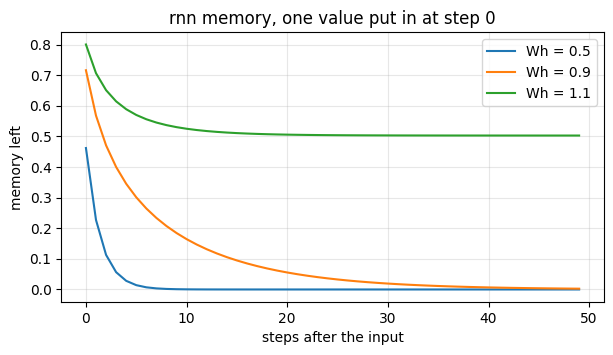

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rnn_decay(Wh, steps=50):
    h, out = 1.0, []
    for t in range(steps):
        h = np.tanh(h * Wh)
        out.append(h)
    return out

plt.figure(figsize=(7,3.5))
for wh in [0.5, 0.9, 1.1]:
    plt.plot(rnn_decay(wh), label='Wh = ' + str(wh))
plt.xlabel('steps after the input'); plt.ylabel('memory left')
plt.legend(); plt.grid(alpha=.3)
plt.title('rnn memory, one value put in at step 0')
plt.show()

Wh = 0.5 is gone in a few steps. even Wh = 1.1 dies because tanh squashes it back. so a plain RNN cannot hold something for 50 steps.

## the LSTM fix, a cell state

an LSTM keeps two things instead of one:

- `c` the **cell state**, this is the actual long term memory
- `h` the **hidden state**, this is what goes out and to the next step

and the update to c is not a multiply by a weight matrix, its this:

```
c_t = f * c_(t-1)  +  i * g
```

`f` is the forget gate and `i` is the input gate, both are between 0 and 1. if f is near 1 and i is near 0 then `c_t = c_(t-1)`, the memory just sits there unchanged for as long as needed.

## the three gates

everything is computed from the same two things, current input and previous hidden state:

| gate | formula | what it decides |
|---|---|---|
| forget `f` | sigmoid(...) | how much of the old cell state to keep |
| input `i` | sigmoid(...) | how much of the new candidate to write in |
| candidate `g` | tanh(...) | what the new information actually is |
| output `o` | sigmoid(...) | how much of the cell state to expose as h |

then:

```
c = f * c_old + i * g
h = o * tanh(c)
```

sigmoid is used for the gates because it gives 0 to 1, wich reads as a percentage. tanh is used for the content because that can be negative.

## holding a value, by hand

setting the gates myself, no training. put a value in at step 0, then close the input gate and keep the forget gate open.

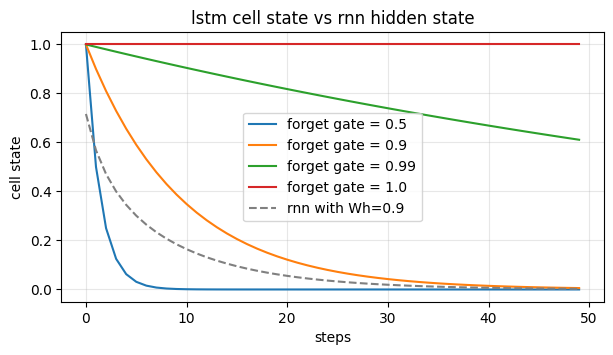

In [7]:
def cell_step(c, x, f, i, g):
    return f * c + i * g

def hold(f_value, steps=50):
    c, out = 0.0, []
    for t in range(steps):
        if t == 0:
            c = cell_step(c, 1.0, f=0.0, i=1.0, g=1.0)   # write the value in
        else:
            c = cell_step(c, 0.0, f=f_value, i=0.0, g=0.0)  # then just hold
        out.append(c)
    return out

plt.figure(figsize=(7,3.5))
for f in [0.5, 0.9, 0.99, 1.0]:
    plt.plot(hold(f), label='forget gate = ' + str(f))
plt.plot(rnn_decay(0.9), '--', color='grey', label='rnn with Wh=0.9')
plt.xlabel('steps'); plt.ylabel('cell state'); plt.legend(); plt.grid(alpha=.3)
plt.title('lstm cell state vs rnn hidden state')
plt.show()

with the forget gate at 1.0 the value is still exactly 1 after 50 steps. thats the whole point, its a straight line and not a decay curve.

and the important part is `f` is **learnt**, so the network itself decides for each slot whether to hold or to drop.

## why the gradient survives

going backward, the RNN multiplies the gradient by Wh at every step, so after 50 steps it has been multiplied 50 times, that either vanishes or explodes.

in the LSTM the path through the cell state is `c_t = f * c_(t-1) + ...` so going back it multiplies by `f`. when f is near 1 the gradient passes through almost unchanged. i measure this properly in notebook 03.

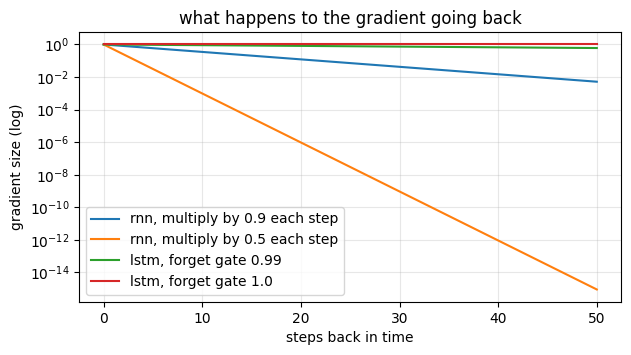

In [4]:
steps = np.arange(0, 51)

plt.figure(figsize=(7,3.5))
plt.semilogy(steps, 0.9 ** steps, label='rnn, multiply by 0.9 each step')
plt.semilogy(steps, 0.5 ** steps, label='rnn, multiply by 0.5 each step')
plt.semilogy(steps, 0.99 ** steps, label='lstm, forget gate 0.99')
plt.semilogy(steps, np.ones_like(steps, dtype=float), label='lstm, forget gate 1.0')
plt.xlabel('steps back in time'); plt.ylabel('gradient size (log)')
plt.legend(); plt.grid(alpha=.3)
plt.title('what happens to the gradient going back')
plt.show()

## a gate is just a switch made of sigmoid

nothing magic in a gate, its a sigmoid layer whose output is multiplied elementwise with something. output near 0 blocks it, near 1 lets it pass.

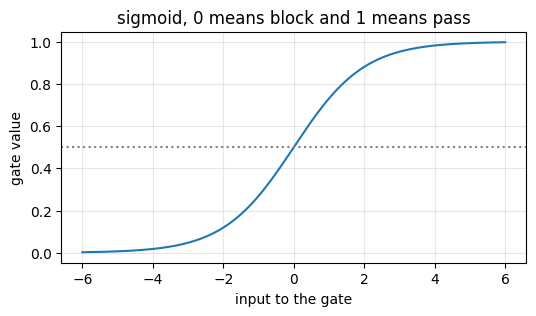

gate at input -3 : 0.047
gate at input  0 : 0.5
gate at input +3 : 0.953


In [5]:
z = np.linspace(-6, 6, 200)
sig = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6,3))
plt.plot(z, sig)
plt.axhline(0.5, ls=':', c='grey')
plt.xlabel('input to the gate'); plt.ylabel('gate value')
plt.title('sigmoid, 0 means block and 1 means pass')
plt.grid(alpha=.3)
plt.show()

print("gate at input -3 :", round(1/(1+np.exp(3)), 3))
print("gate at input  0 :", 0.5)
print("gate at input +3 :", round(1/(1+np.exp(-3)), 3))

this last plot matters more than it looks. the forget gate bias starts at 0 in pytorch, wich means the gate starts at **0.5**, so the cell state gets halved at every step in the beginning. that is a decay of 0.5^t, exactly the thing LSTM was supposed to fix. i ran into this for real in notebook 02.

### recap
- two states, `c` for long memory and `h` for output
- `c_t = f * c_(t-1) + i * g`, addition instead of repeated matrix multiply
- gates are sigmoids, learnt, one value per hidden unit
- with f near 1 both the value and the gradient survive long distances